In [1]:
pip install numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss

# XOR Dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])

# Hyperparameter combinations
experiments = [
    ("Sigmoid", "logistic", 0.01),
    ("Sigmoid", "logistic", 0.1),
    ("ReLU", "relu", 0.01),
    ("ReLU", "relu", 0.1)
]

results = []

for name, activation, lr in experiments:

    mlp = MLPClassifier(
        hidden_layer_sizes=(4,),   # one hidden layer with 4 neurons
        activation=activation,
        learning_rate_init=lr,
        max_iter=1000,
        random_state=42
    )

    mlp.fit(X, y)

    y_pred = mlp.predict(X)
    y_prob = mlp.predict_proba(X)

    accuracy = accuracy_score(y, y_pred)
    loss = log_loss(y, y_prob)

    results.append([
        name,
        lr,
        round(loss, 4),
        round(accuracy * 100, 2)
    ])

# Display results
df = pd.DataFrame(
    results,
    columns=[
        "Activation Function",
        "Learning Rate",
        "Final Loss",
        "Accuracy (%)"
    ]
)

print("\nHyperparameter Experimentation Results\n")
print(df)


Hyperparameter Experimentation Results

  Activation Function  Learning Rate  Final Loss  Accuracy (%)
0             Sigmoid           0.01      0.6943          50.0
1             Sigmoid           0.10      0.0087         100.0
2                ReLU           0.01      0.6937          50.0
3                ReLU           0.10      0.6996          50.0


In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

acc = accuracy_score(y, y_pred)

prec = precision_score(y, y_pred)

rec = recall_score(y, y_pred)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)

Accuracy : 0.5
Precision: 0.5
Recall   : 1.0


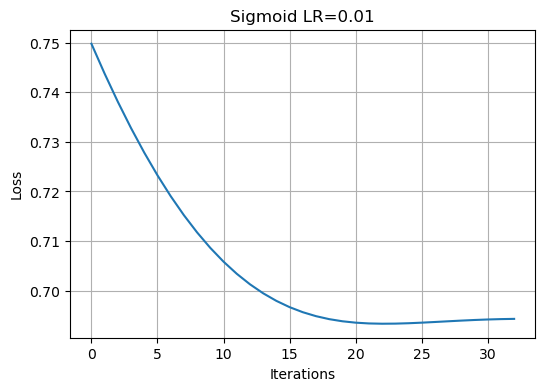

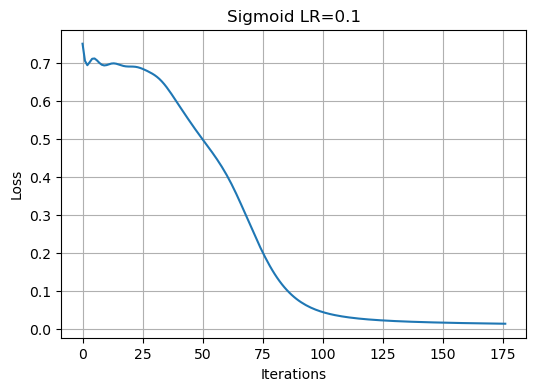

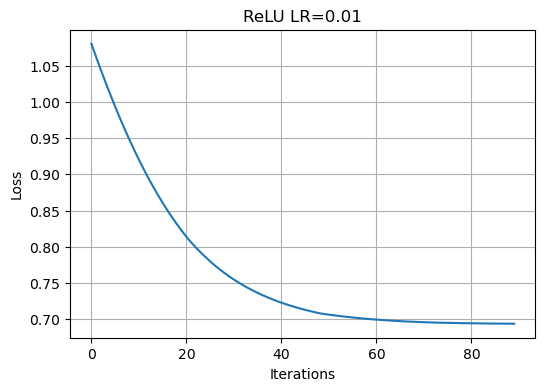

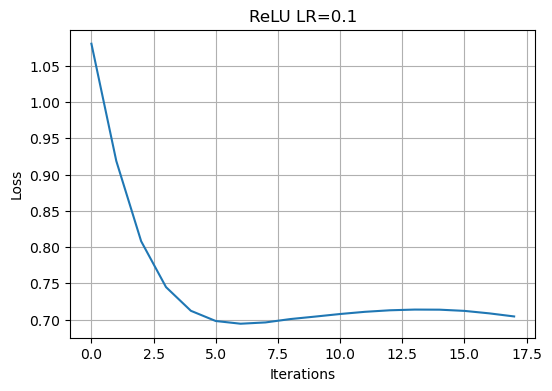

In [4]:
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

configs = [
    ("Sigmoid LR=0.01", "logistic", 0.01),
    ("Sigmoid LR=0.1", "logistic", 0.1),
    ("ReLU LR=0.01", "relu", 0.01),
    ("ReLU LR=0.1", "relu", 0.1)
]

for title, activation, lr in configs:

    mlp = MLPClassifier(
        hidden_layer_sizes=(4,),
        activation=activation,
        learning_rate_init=lr,
        max_iter=1000,
        random_state=42
    )

    mlp.fit(X, y)

    plt.figure(figsize=(6,4))
    plt.plot(mlp.loss_curve_)
    plt.title(title)
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()